In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import random
import time
import matplotlib.pyplot as plt
import sys

In [4]:
S0 = 100.0      # initial stock price
mu = 0.05     # drift
sigma = 0.15  # volatility
r = 0.03      # risk-free rate
M = 1         # maturity

T = 24        # number of time steps
N_MC = int(1e6)  # number of paths

delta_t = 1. / M                # time interval
lamb = np.exp(- r * delta_t)  # discount factor

sigma_d = sigma / np.sqrt(252)

In [5]:
RN = np.random.randn(N_MC, 1)
S1 = S0 * np.exp((mu - 1/2 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN )

In [6]:
S1a = S0 * (1.0 + sigma_d * RN)

In [32]:
S1a.shape, 1/np.sqrt(1./252.)

((1000000, 1), 15.874507866387543)

In [34]:
# The Black-Scholes prices
def bs_put(t, S0, K, r, sigma, T):
    d1arr = d1(S0, K, r, sigma, T)
    d2arr = d2(S0, K, r, sigma, T)
    price = K * np.exp(-r * (T-t)) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return price

def bs_call(t, S0, K, r, sigma, T):
    d1 = d1(S0, K, r, sigma, T)
    d2 = d2(S0, K, r, sigma, T)
    price = S0 * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2)
    return price

def d1(S0, K, r, sigma, T):
    return (np.log(S0/K) + (r + sigma**2 / 2) * T)/(sigma * np.sqrt(T))
 
def d2(S0, K, r, sigma, T):
    return (np.log(S0 / K) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))

def get_delta_1(S, K, sigma, T):
    stock_prices = S
    return norm.cdf((np.log(stock_prices / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)))

def opt_delta(S, K, r, sigma, T):
    return norm.cdf(d1(S, K, r, sigma, T))

In [36]:
D0 = opt_delta(S0, 105., r, sigma, 20./252.)
D1 = opt_delta(S1, 105., r, sigma, 19./252)
D1a = opt_delta(S1a, 105., r, sigma, 19./252)

np.nanmean((np.where(S1>S0, D1, np.NaN) - D0) ), np.nanmean((np.where(S1a>S0, D1a, np.NaN) - D0) )

(0.17990495686080066, 0.038506498409659744)

In [27]:
np.nanmean((np.where(S1>S0, D1, np.NaN) - D0) )

0.17990495686080066

In [23]:
np.nanmean((np.where(S1a>S0, D1a, np.NaN) - D0) )

0.038506498409659744

In [21]:
get_delta(S0, 105., sigma, 20./252.)

0.14071477192852155

In [24]:
np.log(100/105)

-0.048790164169432056

In [28]:
# Parameters for generating stock moves
np.random.seed(42)  # For reproducibility
num_simulations = 10_000  # Number of 1-day stock moves
initial_stock_price = 100  # Assuming initial stock price of $100
daily_volatility = sigma / np.sqrt(252)  # Converting annual volatility to daily volatility

# Generate random 1-day stock returns using geometric Brownian motion
random_returns = np.random.normal(loc=0, scale=daily_volatility, size=num_simulations)
one_day_stock_moves = initial_stock_price * np.exp(random_returns)  # Simulate 1-day stock prices

one_day_stock_moves[:10], len(one_day_stock_moves)  # Show first 10 values and the total count


(array([100.47045393,  99.86943782, 100.61388474, 101.44953324,
         99.77899044,  99.77900592, 101.50340498, 100.72779329,
         99.55737091, 100.51398746]),
 10000)

In [29]:
S1a

array([[ 99.08212219],
       [100.97773933],
       [ 99.67400259],
       ...,
       [101.00373624],
       [100.08130763],
       [100.48878262]])

In [40]:
import numpy as np
from scipy.stats import norm

# Parameters
np.random.seed(42)
S0 = 100  # Initial stock price
K = 105  # Strike price
r = 0.05  # Risk-free rate
sigma = 0.2  # Annual volatility
delta_t = 1 / 252  # 1-day time step

# Generate random normal shocks
N_MC = 1000_000  # Number of Monte Carlo simulations
RN = np.random.randn(N_MC, 1)

# Correct GBM stock price move
S1 = S0 * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN)

# Approximated stock price move
sigma_d = sigma * np.sqrt(delta_t)
S1a = S0 * (1 +  r * delta_t  + sigma_d * RN)

# Define the delta function using d1
def opt_delta(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initial delta
D0 = opt_delta(S0, K, r, sigma, 20 / 252)

# Delta after 1 day using correct and approximated stock prices
D1 = opt_delta(S1, K, r, sigma, 19 / 252)
D1a = opt_delta(S1a, K, r, sigma, 19 / 252)

# Compute the mean delta differences
delta_diff_correct = np.nanmean(np.where(S1 > S0, D1, np.NaN) - D0) / sigma_d
delta_diff_approx = np.nanmean(np.where(S1a > S0, D1a, np.NaN) - D0) / sigma_d

delta_diff_correct, delta_diff_approx


(4.108524492087312, 4.081560160474195)

In [41]:
# Function to calculate Black-Scholes option gamma
def opt_gamma(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

# Example calculation
gamma_example = opt_gamma(S0, K, r, sigma, T=1)  # 1 year to maturity example
gamma_example


0.019835261904213263

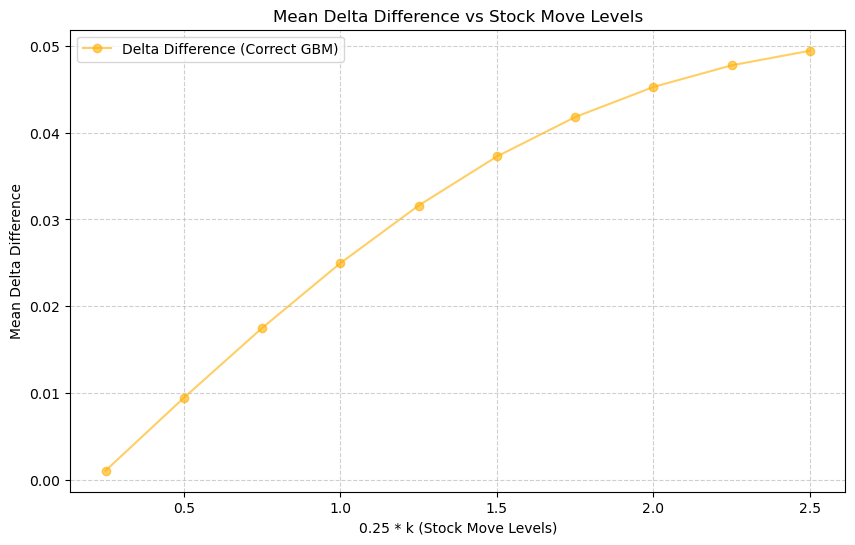

In [47]:
import matplotlib.pyplot as plt

# Define the range of k values
k_values = np.arange(1, 11)  # 1 to 10
delta_diffs_for_k = []

# Compute delta differences for each k level of stock move
for k in k_values:
    threshold = S0 + 0.25 * k * sigma_d * S0  # Define upper bound for S1
    mask = (S1 > S0) & (S1 <= threshold)  # Only consider moves within the range
    
    # Compute mean delta differences for the correct GBM simulation
    delta_diff_k = np.nanmean(np.where(mask, D1, np.NaN) - D0)
    delta_diffs_for_k.append(delta_diff_k)

# Plot the delta differences against k values
plt.figure(figsize=(10, 6))
plt.plot(0.25 * k_values, delta_diffs_for_k, marker='o', linestyle='-', color='#FFAF00', alpha=0.6, label='Delta Difference (Correct GBM)')
plt.xlabel('0.25 * k (Stock Move Levels)')
plt.ylabel('Mean Delta Difference')
plt.title('Mean Delta Difference vs Stock Move Levels')
# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dotted grid for clarity
plt.legend(fontsize=10)
plt.show()


In [48]:
import matplotlib.pyplot as plt

# Customizing the style to give a "paper-like" appearance
plt.style.use('seaborn-paper')  # Base style to start with

# Modify the figure face color and axis background to give a paper-like tone
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background for the canvas
ax.set_facecolor('#FAF0E6')  # Lighter tone for the plot background

# Example data
x = [0.25 * k for k in range(1, 11)]
y = [value ** 1.5 for value in x]  # Just for illustration purposes

# Plotting with markers and line styles
ax.plot(x, y, marker='o', linestyle='-', color='b', label='Delta Difference')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels', fontsize=14)

# Customizing the grid and legend
ax.grid(True, linestyle='--', alpha=0.6)  # Dotted grid for clarity
ax.legend(fontsize=10)

# Display the plot with the paper-like background
plt.show()


OSError: 'seaborn-paper' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

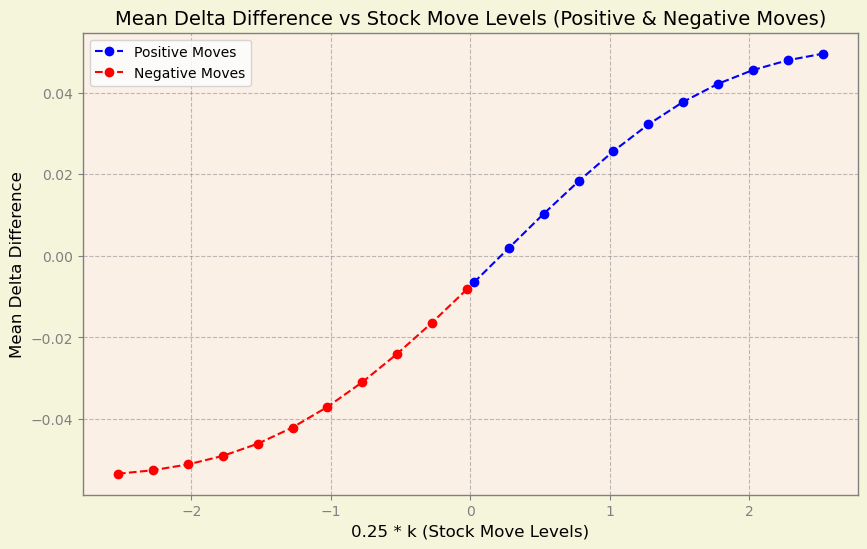

In [54]:
k_values = np.arange(0.1, 11) 
# Compute delta differences for both positive and negative stock price moves
delta_diffs_positive = []
delta_diffs_negative = []

for k in k_values:
    # Define upper and lower bounds for positive and negative moves
    positive_threshold = S0 + 0.25 * k * sigma_d * S0
    negative_threshold = S0 - 0.25 * k * sigma_d * S0
    
    # Mask for positive moves
    mask_positive = (S1 > S0) & (S1 <= positive_threshold)
    delta_diff_pos_k = np.nanmean(np.where(mask_positive, D1, np.NaN) - D0)
    delta_diffs_positive.append(delta_diff_pos_k)
    
    # Mask for negative moves
    mask_negative = (S1 < S0) & (S1 >= negative_threshold)
    delta_diff_neg_k = np.nanmean(np.where(mask_negative, D1, np.NaN) - D0)
    delta_diffs_negative.append(delta_diff_neg_k)

# Plot the delta differences for both positive and negative moves
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background
ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area

# Plotting positive and negative delta differences
ax.plot(0.25 * k_values, delta_diffs_positive, marker='o', linestyle='--', color='b', label='Positive Moves')
ax.plot(-0.25 * k_values, delta_diffs_negative, marker='o', linestyle='--', color='r', label='Negative Moves')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels (Positive & Negative Moves)', fontsize=14)

# Customizing the grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()


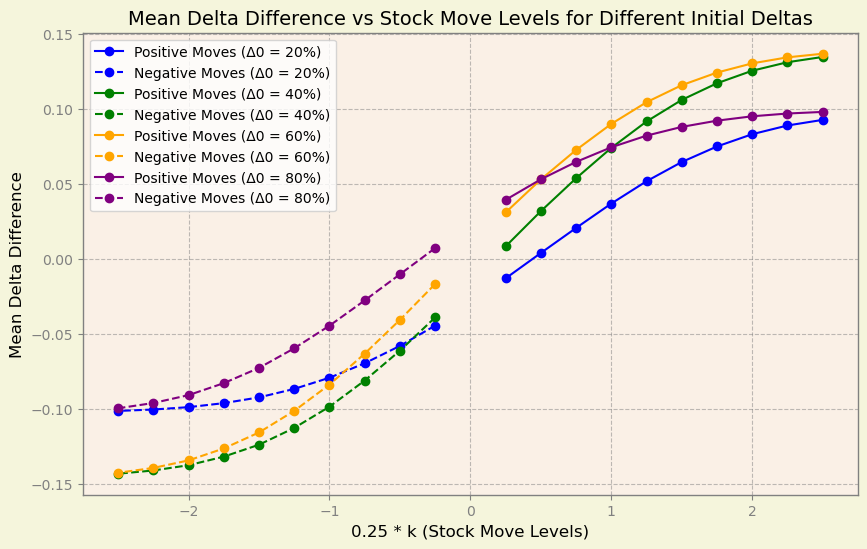

In [ ]:
# Simulate options DDelta
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 100_000  # Number of Monte Carlo simulations
np.random.seed(42)
RN = np.random.randn(N_MC, 1)  # Random normal shocks
sigma_d = sigma * np.sqrt(delta_t)

# Function to calculate option delta
def opt_delta(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initial deltas to evaluate
initial_deltas = [0.2, 0.4, 0.6, 0.8]
colors = ['b', 'g', 'orange', 'purple']  # Colors for different lines
delta_diffs_results = []  # Store results for each initial delta

# Loop through each initial delta level
for initial_delta, color in zip(initial_deltas, colors):
    # Find the initial stock price corresponding to the target delta
    d1_value = norm.ppf(initial_delta)
    initial_S = K * np.exp(d1_value * sigma * np.sqrt(T) - (r + 0.5 * sigma**2) * T)
    
    # Simulate correct stock price moves from initial S
    S1 = initial_S * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN)
    D0 = opt_delta(initial_S, K, r, sigma, T)  # Initial delta

    # Recalculate D1
    D1 = opt_delta(S1, K, r, sigma, - 1.0 / 252 + T)

    # Initialize arrays to store positive and negative delta differences
    delta_diffs_positive = []
    delta_diffs_negative = []

    # Compute delta differences for each k
    for k in np.arange(1, 11):
        positive_threshold = initial_S + 0.25 * k * sigma_d * initial_S
        negative_threshold = initial_S - 0.25 * k * sigma_d * initial_S
        
        # Positive moves
        mask_positive = (S1 > initial_S) & (S1 <= positive_threshold)
        delta_diff_pos_k = np.nanmean(np.where(mask_positive, D1, np.NaN) - D0)
        delta_diffs_positive.append(delta_diff_pos_k)
        
        # Negative moves
        mask_negative = (S1 < initial_S) & (S1 >= negative_threshold)
        delta_diff_neg_k = np.nanmean(np.where(mask_negative, D1, np.NaN) - D0)
        delta_diffs_negative.append(delta_diff_neg_k)
    
    # Store results for plotting
    delta_diffs_results.append((delta_diffs_positive, delta_diffs_negative, initial_delta, color))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background
ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area

# Plot for each initial delta level
for pos_diffs, neg_diffs, initial_delta, color in delta_diffs_results:
    ax.plot(0.25 * np.arange(1, 11), pos_diffs, marker='o', linestyle='-', color=color, label=f'Positive Moves (Δ0 = {int(initial_delta*100)}%)')
    ax.plot(-0.25 * np.arange(1, 11), neg_diffs, marker='o', linestyle='--', color=color, label=f'Negative Moves (Δ0 = {int(initial_delta*100)}%)')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels for Different Initial Deltas', fontsize=14)

# Customizing the grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()


## Mathematical Evaluation

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 100_000  # Number of Monte Carlo simulations

# Function to calculate d1 for given S
def d1(S, K, r, sigma, T):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

# Function to calculate the change in Delta
def delta_change(S0, K, r, sigma, T, N_MC, S_max_factor=1.5):
    # Generate N_MC random paths for stock prices using geometric Brownian motion
    dt = delta_t
    S_paths = np.zeros(N_MC)
    S_paths[:] = S0  # Initialize all paths with S0

    # Simulate stock paths
    for i in range(N_MC):
        # Simulate a random walk for the stock price
        dW = np.random.normal(0, np.sqrt(dt), size=int(T / delta_t))
        log_returns = (r - 0.5 * sigma**2) * delta_t + sigma * dW
        S_paths[i] *= np.exp(np.sum(log_returns))

    # Compute the change in Delta for each simulated stock price
    delta_initial = norm.cdf(d1(S0, K, r, sigma, T))
    delta_change_vals = np.zeros(N_MC)

    for i in range(N_MC):
        delta_new = norm.cdf(d1(S_paths[i], K, r, sigma, T))
        delta_change_vals[i] = delta_new - delta_initial

    # Return the average change in Delta
    return np.mean(delta_change_vals)

# Run the Monte Carlo simulation to evaluate the change in Delta
delta_change_result = delta_change(S0, K, r, sigma, T, N_MC)

# Output the result
delta_change_result


In [63]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity

# Define the PDF of the stock price under the Black-Scholes model
def stock_price_pdf(S_T, S0, K, r, sigma, T):
    return (1 / (S_T * sigma * np.sqrt(2 * np.pi * T))) * np.exp(
        -((np.log(S_T / S0) - (r - 0.5 * sigma**2) * T) ** 2) / (2 * sigma**2 * T)
    )

# Define the d1 formula
def d1(S_T, K, r, sigma, T):
    return (np.log(S_T / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

# Define the change in Delta integrand
def integrand(S_T, S0, K, r, sigma, T):
    delta_initial = norm.cdf(d1(S0, K, r, sigma, T))
    delta_new = norm.cdf(d1(S_T, K, r, sigma, T))
    pdf_value = stock_price_pdf(S_T, S0, K, r, sigma, T)
    return (delta_new - delta_initial) * pdf_value

# Define the function to compute the integral
def compute_delta_change_integral(S0, K, r, sigma, T, k_vals):
    results = {}
    for k in k_vals:
        upper_bound = S0 + k * sigma * S0
        integral, _ = quad(integrand, S0, upper_bound, args=(S0, K, r, sigma, T))
        results[k] = integral
    return results

# Define k values
k_vals = np.arange(0.05, 5.05, 0.25)

# Compute the integrals for each k
delta_change_integrals = compute_delta_change_integral(S0, K, r, sigma, T, k_vals)

# Display the results
delta_change_integrals


{0.05: 0.002853375005895732,
 0.3: 0.07517924940034641,
 0.55: 0.0896152483174065,
 0.8: 0.0897234429819806,
 1.05: 0.08972351658829601,
 1.3: 0.08972351659558245,
 1.55: 0.08972351659558231,
 1.8: 0.08972351659558264,
 2.05: 0.08972351659558235,
 2.3: 0.08972351659558254,
 2.55: 0.08972351659558245,
 2.8: 0.08972351659558278,
 3.05: 0.08972351659558259,
 3.3: 0.08972351659558267,
 3.55: 0.08972351659558254,
 3.8: 0.08972351659558235,
 4.05: 0.08972351659558239,
 4.3: 0.08972351659558236,
 4.55: 0.08972351659558245,
 4.8: 0.08972351659558242}

In [ ]:
# MC Dleta Simualtions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

class OptionDeltaSimulator:
    def __init__(self, S0, K, r, sigma, T, delta_t, N_MC):
        """
        Initializes the OptionDeltaSimulator class with the provided parameters.
        
        Parameters:
        - S0: Initial stock price
        - K: Strike price
        - r: Risk-free rate
        - sigma: Volatility
        - T: Time to maturity
        - delta_t: Time step for the simulation
        - N_MC: Number of Monte Carlo simulations
        """
        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.delta_t = delta_t
        self.N_MC = N_MC
    
    def d1(self, S_T):
        """
        Calculate the d1 value for the Black-Scholes model for a given stock price S_T.
        
        Parameters:
        - S_T: Stock price at time T
        
        Returns:
        - d1 value for the given stock price
        """
        return (np.log(S_T / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))

    def simulate(self):
        """
        Simulates the change in Delta for an option and computes the difference in Delta.
        
        This method uses Monte Carlo simulations to simulate stock price paths and calculates
        the change in Delta based on the initial and final stock prices.
        
        Returns:
        - delta_changes: List of delta changes from simulation
        """
        delta_initial = norm.cdf(self.d1(self.S0))  # Initial delta
        
        delta_changes = []
        for i in range(self.N_MC):
            # Simulate the random walk for the stock price
            dW = np.random.normal(0, np.sqrt(self.delta_t), size=int(self.T / self.delta_t))
            log_returns = (self.r - 0.5 * self.sigma**2) * self.delta_t + self.sigma * dW
            S_T = self.S0 * np.exp(np.sum(log_returns))  # Simulated stock price

            # Compute the new delta and the change in delta
            delta_new = norm.cdf(self.d1(S_T))
            delta_change = delta_new - delta_initial
            delta_changes.append(delta_change)
        
        return np.array(delta_changes)
    
    def plot(self, delta_changes):
        """
        Plots the distribution of delta changes based on the simulation.
        
        Parameters:
        - delta_changes: List or array of delta changes from the simulation
        """
        plt.figure(figsize=(8, 6))
        plt.hist(delta_changes, bins=50, alpha=0.75, color='blue', edgecolor='black')
        plt.title("Distribution of Delta Changes")
        plt.xlabel("Delta Change")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

# Example usage
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 100_000  # Number of Monte Carlo simulations

# Create the simulator object
simulator = OptionDeltaSimulator(S0, K, r, sigma, T, delta_t, N_MC)

# Simulate delta changes
delta_changes = simulator.simulate()

# Plot the results
simulator.plot(delta_changes)


In [ ]:
# Cursor by simulation
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import List, Tuple

class OptionDeltaSimulator:
    def __init__(self, S0: float, K: float, r: float, sigma: float, T: float, delta_t: float):
        """
        Initialize the Option Delta Simulator.
        
        Parameters:
        - S0: Initial stock price
        - K: Strike price
        - r: Risk-free rate
        - sigma: Volatility
        - T: Time to maturity (in years)
        - delta_t: Time step for simulation (in years)
        """
        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.delta_t = delta_t
        self.sigma_d = sigma * np.sqrt(delta_t)
    
    def _calculate_d1(self, S: float, t: float) -> float:
        """Calculate d1 term in Black-Scholes formula."""
        return (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * t) / (self.sigma * np.sqrt(t))
    
    def _calculate_delta(self, S: float, t: float) -> float:
        """Calculate option delta."""
        return norm.cdf(self._calculate_d1(S, t))
    
    def simulate(self, initial_delta: float, N_MC: int = 100_000) -> Tuple[List[float], List[float]]:
        """
        Simulate delta changes for a given initial delta.
        
        Parameters:
        - initial_delta: Target initial delta (between 0 and 1)
        - N_MC: Number of Monte Carlo simulations
        
        Returns:
        - Tuple of (positive_delta_diffs, negative_delta_diffs)
        """
        # Find initial stock price for target delta
        d1_value = norm.ppf(initial_delta)
        initial_S = self.K * np.exp(d1_value * self.sigma * np.sqrt(self.T) - 
                                  (self.r + 0.5 * self.sigma**2) * self.T)
        
        # Generate random normal shocks
        RN = np.random.randn(N_MC, 1)
        
        # Simulate stock price moves
        S1 = initial_S * np.exp((self.r - 0.5 * self.sigma**2) * self.delta_t + 
                               self.sigma * np.sqrt(self.delta_t) * RN)
        
        # Calculate initial and final deltas
        D0 = self._calculate_delta(initial_S, self.T)
        D1 = self._calculate_delta(S1, self.T - self.delta_t)
        
        delta_diffs_positive = []
        delta_diffs_negative = []
        
        # Calculate delta differences for different move sizes
        for k in np.arange(1, 11):
            pos_threshold = initial_S + 0.25 * k * self.sigma_d * initial_S
            neg_threshold = initial_S - 0.25 * k * self.sigma_d * initial_S
            
            # Positive moves
            mask_pos = (S1 > initial_S) & (S1 <= pos_threshold)
            delta_diff_pos = np.nanmean(np.where(mask_pos, D1, np.NaN) - D0)
            delta_diffs_positive.append(delta_diff_pos)
            
            # Negative moves
            mask_neg = (S1 < initial_S) & (S1 >= neg_threshold)
            delta_diff_neg = np.nanmean(np.where(mask_neg, D1, np.NaN) - D0)
            delta_diffs_negative.append(delta_diff_neg)
            
        return delta_diffs_positive, delta_diffs_negative
    
    def plot(self, results: List[Tuple[List[float], List[float], float]], 
            title: str = "Mean Delta Difference vs Stock Move Levels"):
        """
        Plot delta differences for multiple initial deltas.
        
        Parameters:
        - results: List of tuples (positive_diffs, negative_diffs, initial_delta)
        - title: Plot title
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#F5F5DC')
        ax.set_facecolor('#FAF0E6')
        
        colors = ['b', 'g', 'orange', 'purple']
        k_values = np.arange(1, 11)
        
        for (pos_diffs, neg_diffs, initial_delta), color in zip(results, colors):
            ax.plot(0.25 * k_values, pos_diffs, marker='o', linestyle='-', 
                   color=color, label=f'Positive Moves (Δ0 = {int(initial_delta*100)}%)')
            ax.plot(-0.25 * k_values, neg_diffs, marker='o', linestyle='--', 
                   color=color, label=f'Negative Moves (Δ0 = {int(initial_delta*100)}%)')
        
        ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
        ax.set_ylabel('Mean Delta Difference', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.grid(True)
        ax.legend(fontsize=10)
        
        plt.show()

# Example usage:
if __name__ == "__main__":
    simulator = OptionDeltaSimulator(
        S0=100, K=105, r=0.05, sigma=0.2, 
        T=5/252, delta_t=1/252
    )
    
    results = []
    for delta in [0.2, 0.4, 0.6, 0.8]:
        pos_diffs, neg_diffs = simulator.simulate(delta)
        results.append((pos_diffs, neg_diffs, delta))
    
    simulator.plot(results)